In [1]:
import pandas as pd
import cupy as cp
import cudf
import cuml
import torch
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns
from cuml.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

In [2]:
df_pandas = pd.read_csv('household_power_consumption_not_null.csv', parse_dates=[['Date', 'Time']],
                       date_format = {'Date': '%d/%m/%Y', 
                                      'Time': '%H:%M:%S'},
                       dayfirst = True)
df_pandas

/tmp/ipykernel_17210/4030125953.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df_pandas = pd.read_csv('household_power_consumption_not_null.csv', parse_dates=[['Date', 'Time']],


,Date_Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...
2049275,2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2049276,2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2049277,2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2049278,2010-11-26 21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [3]:
df_cudf_1 = cudf.DataFrame(df_pandas)
df_cudf_1

,Date_Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...
2049275,2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2049276,2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2049277,2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2049278,2010-11-26 21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [4]:
df_cudf_1 = df_cudf_1.astype(float)
df_cudf_1

,Date_Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,1.166290e+18,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,1.166290e+18,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,1.166290e+18,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,1.166290e+18,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,1.166290e+18,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...
2049275,1.290805e+18,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2049276,1.290805e+18,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2049277,1.290805e+18,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2049278,1.290805e+18,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [5]:
class Clustering(object):

    def __init__(self, dataset, plotting_type: str, n_clusters: int, metric: str, connectivity: str, linkage: str,
                 c: int, verbose: bool, output_type: str,
                 plotting_x: str, plotting_y: str,):
        self.dataset = dataset.copy().reset_index(drop = True)
        self.plotting_type = plotting_type
        self.n_clusters = n_clusters
        self.metric = metric
        self.connectivity = connectivity
        self.linkage = linkage
        self.c = c
        self.verbose = verbose
        self.output_type = output_type
        self.plotting_x = plotting_x
        self.plotting_y = plotting_y

    def AgglomerativeClustering(self):
        global aggclust_global
        global labels_global
        global cluster_centers_global
        
        aggclust_float = cuml.cluster.AgglomerativeClustering(n_clusters=self.n_clusters, 
                                                              metric=self.metric, connectivity=self.connectivity, 
                                                              linkage=self.linkage, c=self.c, 
                                                              verbose=self.verbose, output_type=self.output_type)
        aggclust = aggclust_float.fit(self.dataset)
        aggclust_global = aggclust

        labels = aggclust_float.labels_
        labels_global = labels
        labels_global = cudf.DataFrame(labels, columns=['Labels'])

    def labels_concat(self):
        global df_concat_global
        global df_concat_pandas_global

        df_concat = cudf.concat([df_cudf_1, labels_global], axis=1)
        df_concat_global = df_concat

        df_concat_pandas = df_concat.to_pandas()
        df_concat_pandas_global = df_concat_pandas

    def plotting(self):

        if self.plotting_type == 'matplotlib':
            x=df_concat_pandas_global[self.plotting_x]
            y=df_concat_pandas_global[self.plotting_y]
            Cluster = df_concat_pandas_global['Labels']

            fig = plt.figure()
            ax = fig.add_subplot(111)
            scatter = ax.scatter(x,y,c=Cluster,s=50)
            plt.colorbar(scatter)
            plt.xlabel(self.plotting_x)
            plt.ylabel(self.plotting_y)

            fig.show()

            # Reduce to 2 dimensions
            pca = PCA(n_components=2)
            X_pca = pca.fit_transform(df_concat_pandas_global)

            # Plot the reduced data
            plt.figure(figsize=(8, 6))
            scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_concat_pandas_global['Labels'], 
                                  cmap='coolwarm', s=50)

            plt.title("Clustering Labels visualized via PCA")
            plt.show()

        elif self.plotting_type == 'seaborn':
            
            sns.scatterplot(data=df_concat_pandas_global, x=self.plotting_x, y=self.plotting_y, hue='Labels', 
                            palette='Set1')
            plt.show()
        
        
    def main(self):
        st = time.time()
        self.AgglomerativeClustering()
        et = time.time()
        elapsed_time = et - st
        print('Execution time:', elapsed_time, 'seconds')
        st = time.time()
        self.labels_concat()
        et = time.time()
        elapsed_time = et - st
        print('Execution time:', elapsed_time, 'seconds')
        st = time.time()
        self.plotting()
        et = time.time()
        elapsed_time = et - st
        print('Execution time:', elapsed_time, 'seconds')
        

In [6]:
clust_matplotlib = Clustering(df_cudf_1, 'matplotlib', 10, 'euclidean', 'knn', 'single', 15,
                              False, None, 
                              'Global_active_power', 'Voltage')

Execution time: 6507.743393421173 seconds
Execution time: 0.0739140510559082 seconds


/tmp/ipykernel_17210/3970726796.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


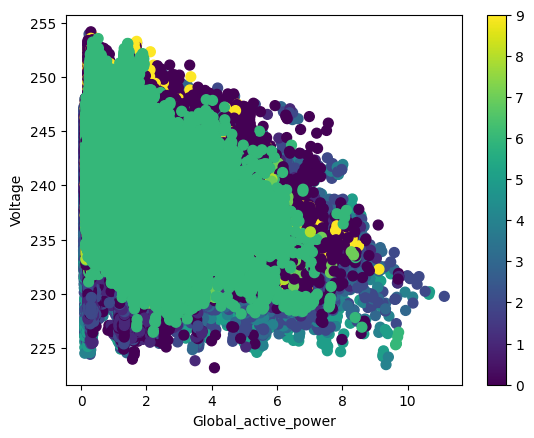

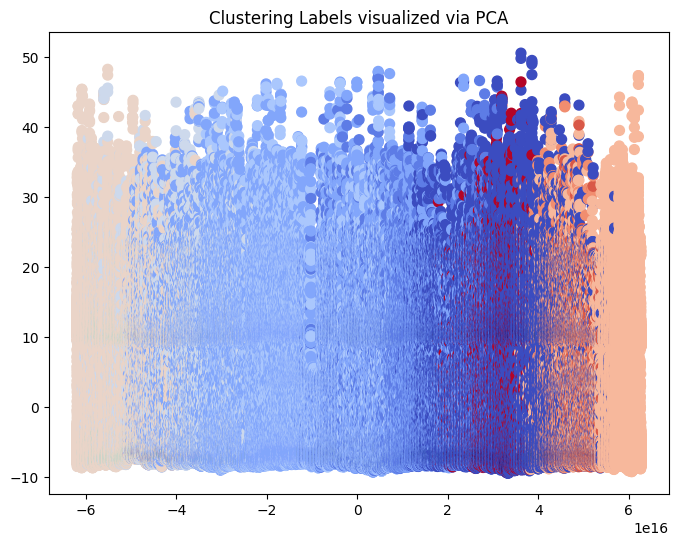

Execution time: 38.21431064605713 seconds


In [7]:
clust_matplotlib.main()

In [8]:
clust_seaborn = Clustering(df_cudf_1, 'seaborn', 2, 'euclidean', 'knn', 'single', 15,
                              False, None, 
                              'Global_active_power', 'Voltage')

Execution time: 6619.915508270264 seconds
Execution time: 0.06213808059692383 seconds


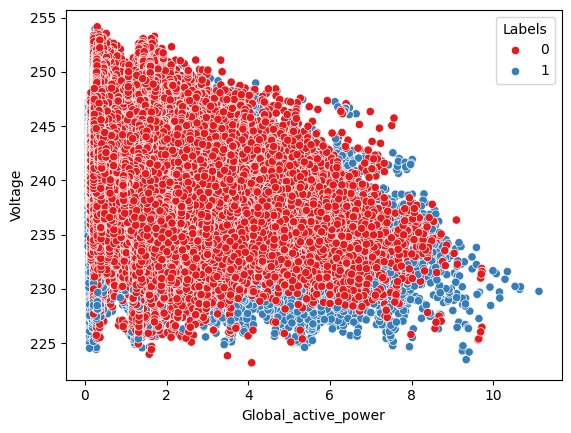

Execution time: 23.601043701171875 seconds


In [9]:
clust_seaborn.main()